# Lab 02: Where Is the Star, and How Sure Are You Allowed to Be?

**ASTR 457, Fall 2026, posted Thu Sep 10, due Wed Sep 16 by Noon (fork → PR, as always)**

*Why this lab: centroiding is how every position in every catalog you'll ever use was measured, and the Cramér–Rao bound is the professional's sanity check (the best precision any measurement can claim) that tells you instantly when an error bar in a paper (or from an AI) is too good to be true.*

Every one of you has your own dataset: `data/<your netid>.csv`, with a single column `x`,
the arrival positions, in pixels, of individual photons on a 1-D detector window spanning
$[0, 64]$ px. Most of the photons come from a star whose image on the detector is a Moffat
profile centered at $x_0$, with shape parameters $\beta = 2.5$ and $r_0 = 4$ px (both known
to you). The rest are **background**: a fraction $f_{\rm bg}$ of the photons, spread uniformly
across the window. I know the true $x_0$ and $f_{\rm bg}$ for your dataset. You don't, and you
can't look them up, and your classmates' values are different from yours. (So are their photon
counts, so your Part 2 bound is yours alone.)

**How this is graded.** Not on whether your code runs, but on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$x_0$ and $f_{\rm bg}$ are to your truth **in units of your own reported uncertainty**. Report
tiny error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.
And this week there is a floor under "huge": your reported $\sigma_{x_0}$ may not exceed
**3× the Cramér–Rao bound** you compute in Part 2. An error bar bigger than that is not
caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive estimator (15%)

Load your photon list and plot a histogram of the arrival positions (choose your binning
deliberately, and you'll defend it). Then estimate the star's position the obvious way: the
**sample mean** of all the photon positions, with uncertainty $s/\sqrt{N}$ (the standard
error of the mean). Report $\hat{x}_0 \pm \sigma$.

Then answer, in a few sentences: is this estimator biased for *your* dataset, and why?
Which way does the bias pull, and what controls its size? (This estimator is *supposed* to
be biased. Understanding exactly how (and what the background has to do with it) is the
point.)

557
38.32985196229803
0.42621141102622384


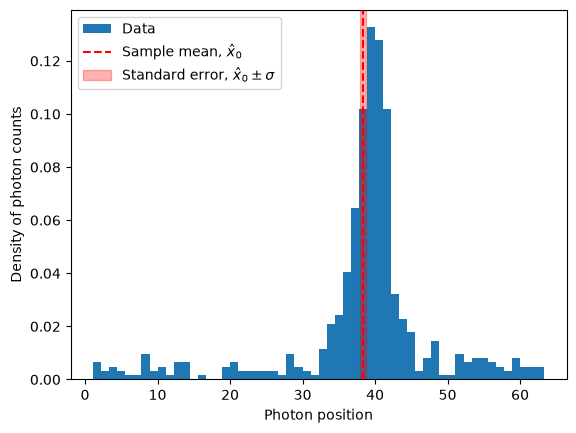

In [36]:
# Part 1: your work here

import numpy as np
import matplotlib.pyplot as plt

data = np.genfromtxt('../../labs/02/data/cmemery2.csv', skip_header=1)

sampleMean = data.mean()
sampleMeanSigma = data.std() / np.sqrt(len(data))


print(len(data))
print(sampleMean)
print(sampleMeanSigma)

fig, ax = plt.subplots()
n, bins, _ = ax.hist(data, bins=56, density=True, label='Data')
ax.axvline(sampleMean, c='r', ls='--', label=r'Sample mean, $\hat x_0$')
ax.axvspan(sampleMean-sampleMeanSigma, sampleMean+sampleMeanSigma, 
           alpha=.3, color='r', label=r'Standard error, $\hat x_0 \pm \sigma$')
ax.set_ylabel('Density of photon counts'); ax.set_xlabel('Photon position')
ax.legend()

**ANSWER (a few sentences):**

$\hat x _0 \pm \sigma = 38.330 \pm 0.426$ 

This estimator is biased for my dataset, since background photons provide a noisy baseline. This bias pulls the sample mean to the left of the approximately gaussian-looking peak, which is what i want to use the mean to describe, implying that this is not a great statistic to describe this data. The bias strength can be larger if the background photon count is larger relative to that of the source photon count, or if the source position is further away from the mean of the background where center of the detector is, close to $x \approx 32$

## Part 2: Estimators you can defend (40%)

Now do it properly. Estimate $x_0$ **three more ways** and compare:

1. **The median** of the photon positions. Robust, simple, but is it unbiased here, and
   what is its variance? (You may answer the variance question empirically in Part 3.)
2. **A sigma-clipped mean**: iteratively remove photons far from the current estimate,
   re-estimate, repeat until it converges. Be explicit about your clipping threshold and
   why you chose it.
3. **Maximum likelihood on the mixture model.** Each photon is background with probability
   $f_{\rm bg}$, or from the star otherwise, so the probability density for a single photon at
   position $x$ is

   $$p(x \mid x_0, f_{\rm bg}) \;=\; \frac{f_{\rm bg}}{64} \;+\; (1 - f_{\rm bg})\,
   \frac{\Gamma(\beta)}{r_0\sqrt{\pi}\,\Gamma(\beta - \tfrac{1}{2})}
   \left[1 + \left(\frac{x - x_0}{r_0}\right)^2\right]^{-\beta}$$

   with $\beta = 2.5$ and $r_0 = 4$ px. Maximize $\sum_i \ln p(x_i \mid x_0, f_{\rm bg})$ over
   both parameters (see Ivezić, Connolly, VanderPlas & Gray, §4.2, for the machinery; this
   is the same likelihood game with different symbols). Get uncertainties from the curvature
   of the log-likelihood at its peak (the observed information), and say so.

Then compute the **Cramér–Rao bound**: the smallest variance any unbiased estimator of $x_0$
can achieve given your $N$ photons. The per-photon Fisher information
$I(x_0) = \int \frac{1}{p}\left(\frac{\partial p}{\partial x_0}\right)^2 dx$ is yours to
evaluate (numerically over the window is fine) and the bound is
$\sigma_{x_0} \geq 1/\sqrt{N\,I}$. Treat both parameters as unknown: the honest bound comes
from inverting the $2\times 2$ Fisher matrix, not the $x_0$ term alone. How close does each
of your four estimators get?

(Two technicalities you may use without proof: photons landing outside the window were lost,
but for your $x_0$ the lost fraction is negligible, and checking that claim makes a fine
Part 3 sensitivity test. And for simulating: a 1-D Moffat with exponent $\beta$ is a
Student-$t$ distribution with $\nu = 2\beta - 1$ degrees of freedom, scaled by
$r_0/\sqrt{\nu}$.)

Commit to a **final answer**, one $x_0 \pm \sigma$ and $f_{\rm bg} \pm \sigma$ you'd put in
a paper, and justify the choice. State clearly how you estimated your uncertainties and why
you believe them. Remember the 3× rule from the header.

In [2]:
# Part 2: your work here

# Median
sampleMedian = np.median(data) 
# Bootstrap median to find variance
# resample x data with replacement, find median each time
rng_bs = np.random.default_rng()
n_boot = 10000
n = len(data)
medianBoots = np.empty(n_boot)
for j in range(n_boot):
    idx = rng_bs.integers(0, n, size=n)
    medianBoots[j] = np.median(data[idx])
medianBootSigma = np.std(medianBoots)

# Sigma clipping
k=3
def sigma_clip_fit(x, k, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        mean = np.mean(x[mask])
        std = np.std(x[mask])
        distance = (x - mean) / std
        new_mask = np.abs(distance) < k
        if np.array_equal(new_mask, mask):
            break
        mask = new_mask
    return mean, mask
meanClipped, maskClipped = sigma_clip_fit(data, k)
f_bg_clip = np.sum(~maskClipped)/len(data)

clipBoots = np.empty(n_boot)
clipFbg = np.empty(n_boot)
for j in range(n_boot):
    idx = rng_bs.integers(0, n, size=n)
    clipBoots[j], clipMask = sigma_clip_fit(data[idx], k)
    clipFbg[j] = np.sum(~clipMask)/len(data) #Only keep track of f_bg
clipBootsSigma = np.std(clipBoots)
f_bg_clipSigma = np.std(clipFbg)

#Takes 4.4s to run

In [3]:
# Mixture modelling

from scipy.optimize import minimize
from scipy.stats import norm
from scipy.special import gamma

beta = 2.5
r0 = 4.0
def p(x, x0, f_bg):
    star = gamma(beta) / (r0 * np.sqrt(np.pi) * gamma(beta - 0.5)) * \
        (1.0 + ((x - x0) / r0)**2)**(-beta)
    return f_bg / 64.0 + (1.0 - f_bg) * star
def neg_log_likelihood(theta, x):
    x0, f_bg = theta
    f_bg = np.clip(f_bg, 1e-6, 1 - 1e-6)
    return -np.sum(np.log(p(x, x0, f_bg)))

#Use k sigma clip for a initial guess for x0, f_bg
theta0 = [sampleMedian, np.mean(~maskClipped)]
result = minimize(neg_log_likelihood, theta0, args=(data,), method='Nelder-Mead')
x0_mix, f_bg_mix = result.x

#bootstrap for sigma
n_boot=5000
n = len(data)
x0_mixBoots = np.empty(n_boot)
f_bg_mixBoots = np.empty(n_boot)
for j in range(n_boot):
    idx = rng_bs.integers(0, n, size=n)
    result_boot = minimize(neg_log_likelihood, [x0_mix, f_bg_mix],
        args=(data[idx],),method='Nelder-Mead')
    x0_mixBoots[j], f_bg_mixBoots[j] = result_boot.x
x0_mixSigma = np.std(x0_mixBoots)
f_bg_mixSigma = np.std(f_bg_mixBoots)

#Takes ~12 sec to run

Text(0.5, 0.98, 'Bootstrapping plots for sample median, clipping, and mix modelling')

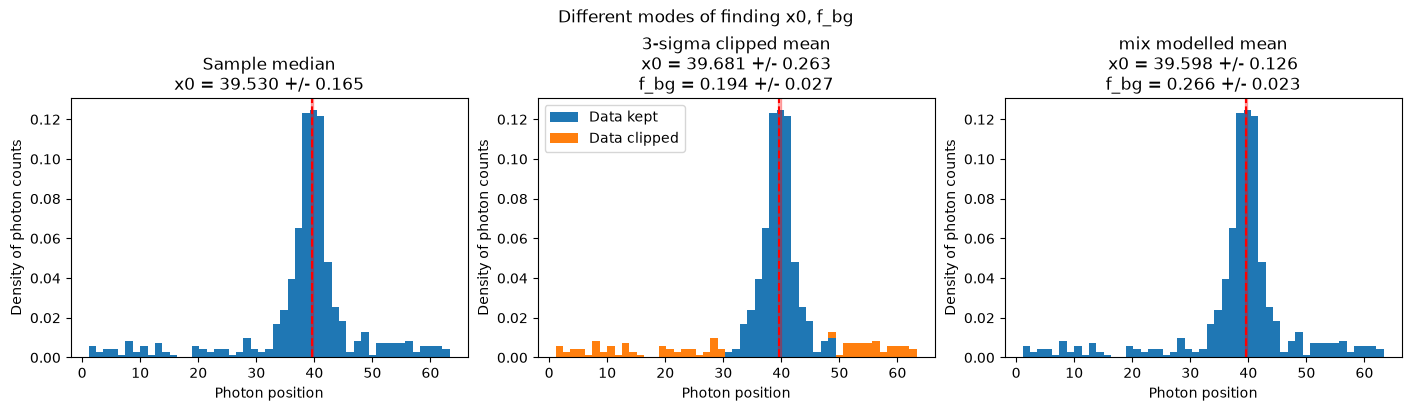

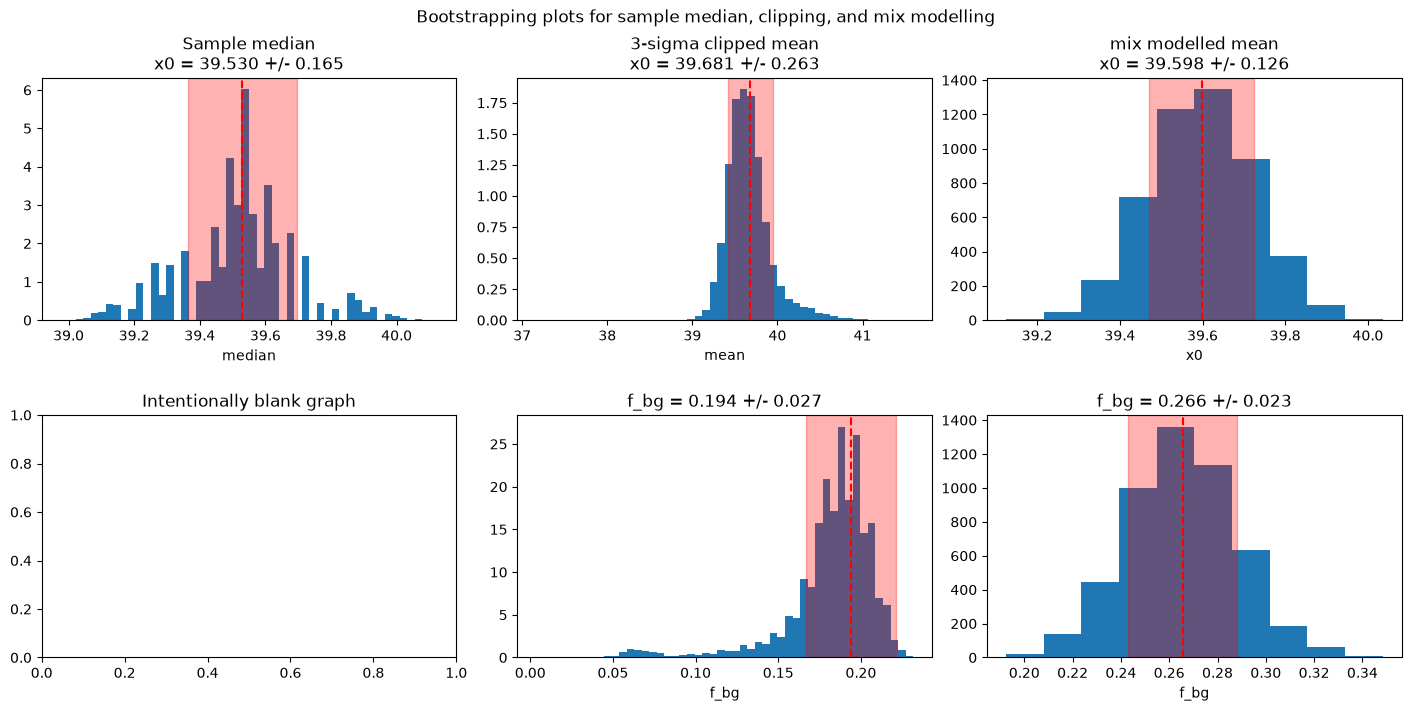

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
bins = np.linspace(min(data), max(data), 50)
n, bins, _ = ax[0].hist(data, bins=bins, density=True, label='Data')
n, bins, _ = ax[1].hist([data[maskClipped], data[~maskClipped]], 
                        bins=bins, density=True, label=['Data kept', 'Data clipped'], stacked=True)
n, bins, _ = ax[2].hist(data, bins=bins, density=True, label='Data')
ax[0].axvline(sampleMedian, c='r', ls='--', label=r'Sample median, $\hat x_0$')
ax[0].axvspan(sampleMedian-medianBootSigma, sampleMedian+medianBootSigma, 
           alpha=.3, color='r', label=r'Standard error, $\hat x_0 \pm \sigma$')
ax[1].axvline(meanClipped, c='r', ls='--')
ax[1].axvspan(meanClipped-clipBootsSigma, meanClipped+clipBootsSigma, alpha=.3, color='r')
ax[2].axvline(x0_mix, c='r', ls='--')
ax[2].axvspan(x0_mix-x0_mixSigma, x0_mix+x0_mixSigma, alpha=.3, color='r')
ax[0].set_ylabel('Density of photon counts'); ax[0].set_xlabel('Photon position')
ax[1].set_ylabel('Density of photon counts'); ax[1].set_xlabel('Photon position');ax[1].legend()
ax[2].set_ylabel('Density of photon counts'); ax[2].set_xlabel('Photon position')
ax[2].set_ylabel('Density of photon counts'); ax[2].set_xlabel('Photon position')
ax[0].set_title(f'Sample median\nx0 = {sampleMedian:.3f} +/- {medianBootSigma:.3f}')
ax[1].set_title(f'{k}-sigma clipped mean\nx0 = {meanClipped:.3f} +/- {clipBootsSigma:.3f}'+
                f'\nf_bg = {f_bg_clip:.3f} +/- {f_bg_clipSigma:.3f}')
ax[2].set_title(f'mix modelled mean\nx0 = {x0_mix:.3f} +/- {x0_mixSigma:.3f}'+
                f'\nf_bg = {f_bg_mix:.3f} +/- {f_bg_mixSigma:.3f}')
fig.suptitle('Different modes of finding x0, f_bg')


fig, ax = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
# bins = np.linspace(min(data), max(data), 50)
bins=50
ax[0,0].hist(medianBoots, bins=bins, density=True)
ax[0,0].axvline(sampleMedian, c='r', ls='--', label=r'Sample median, $\hat x_0$')
ax[0,0].axvspan(sampleMedian-medianBootSigma, sampleMedian+medianBootSigma, 
           alpha=.3, color='r', label=r'Standard error, $\hat x_0 \pm \sigma$')

ax[0,1].hist(clipBoots, bins=bins,density=True)
ax[1,1].hist(clipFbg, bins=bins,density=True)
ax[0,1].axvline(meanClipped, c='r', ls='--')
ax[0,1].axvspan(meanClipped-clipBootsSigma, meanClipped+clipBootsSigma, alpha=.3, color='r')
ax[1,1].axvline(f_bg_clip, c='r', ls='--')
ax[1,1].axvspan(f_bg_clip-f_bg_clipSigma, f_bg_clip+f_bg_clipSigma, alpha=.3, color='r')

ax[0,2].hist(x0_mixBoots)
ax[1,2].hist(f_bg_mixBoots)
ax[0,2].axvline(x0_mix, c='r', ls='--')
ax[0,2].axvspan(x0_mix-x0_mixSigma, x0_mix+x0_mixSigma, alpha=.3, color='r')
ax[1,2].axvline(f_bg_mix, c='r', ls='--')
ax[1,2].axvspan(f_bg_mix-f_bg_mixSigma, f_bg_mix+f_bg_mixSigma, alpha=.3, color='r')

ax[0,0].set_title(f'Sample median\nx0 = {sampleMedian:.3f} +/- {medianBootSigma:.3f}')
ax[0,1].set_title(f'{k}-sigma clipped mean\nx0 = {meanClipped:.3f} +/- {clipBootsSigma:.3f}')
ax[1,1].set_title(f'\nf_bg = {f_bg_clip:.3f} +/- {f_bg_clipSigma:.3f}')
ax[0,2].set_title(f'mix modelled mean\nx0 = {x0_mix:.3f} +/- {x0_mixSigma:.3f}')
ax[1,2].set_title(f'\nf_bg = {f_bg_mix:.3f} +/- {f_bg_mixSigma:.3f}')
ax[0,0].set_xlabel('median')
ax[0,1].set_xlabel('mean'); ax[1,1].set_xlabel('f_bg')
ax[0,2].set_xlabel('x0'); ax[1,2].set_xlabel('f_bg')
ax[1,0].set_title('Intentionally blank graph')
fig.suptitle('Bootstrapping plots for sample median, clipping, and mix modelling')


In [10]:
#Cramer rao bound

from scipy.integrate import quad

def p(x, x0, f_bg):
    star = gamma(beta) / (r0 * np.sqrt(np.pi) * gamma(beta - 0.5)) * \
        (1.0 + ((x - x0) / r0)**2)**(-beta)
    return f_bg / 64.0 + (1.0 - f_bg) * star
def dp_dx0(x, x0, f_bg):
    u = (x - x0) / r0
    return ((1 - f_bg) * gamma(beta) / (r0 * np.sqrt(np.pi) * gamma(beta - 0.5)) *\
             2 * beta / r0 * u * (1 + u**2)**(-beta - 1))

#let x0, f_bg be my best guesses
x0, f_bg = x0_mix, f_bg_mix
I, err = quad(
    lambda x: (dp_dx0(x, x0, f_bg)**2) / p(x, x0, f_bg),
    min(data), max(data)
)
sigma_x0_min = 1/np.sqrt(len(data) * I)
print(sigma_x0_min)

0.12460471888341842


**FINAL ANSWER:** $x_0 = $ 39.598 $\pm$ 0.124 px , $f_{\rm bg} = $ .266 $\pm$ .023 , Cramér–Rao bound $\sigma_{x_0}^{\rm CRB} = $ 0.125 px

**Justification and uncertainty method (a short paragraph):**

I trust the mixture model's f_bg more than the sigma clipping's f_bg since the sigma clipping doesn't remove the background noise that is near the source peak. So it thinks that noise + source is 'the true source' to pull from. Also the sigma clipped mean can be biased right or left if noise near x happens to be not very uniformly distributed. Also, I trust the mixture model more than the sample median. Although they give very similar numbers, I think it's better that the mixture model is trying to actually fit a model of source + background to the data instead of just finding the peak like the sample median is doing.

For the sample mean, sample median, sigma clipped median, and mixture models, the errors are 0.426, 0.170, 0.257, and 0.124. For the sample mean, i just did the mean error std/sqrt(n), but for everything else i bootstrapped 10,000 times for sample median/sigma clip estimators, and bootstrapped the mixture model 5,000 times. I trust the sigmas are accurate to each method, since you can see over thousands of resampling of the original data, the sigma describes where the estimated x0 lands. We see that the mixture model reaches the cramer rao bound, 0.125, pretty well. I assume its alright that the mixture model has a slightly lower value than the minimum given by the cramer rao bound, since the cramer rao bound is only appoximated & isn't calculated with the full matrix calculation.

Also, i trust this answer the best because of the verification that I do in part 3. It seems like while sigma clipping & mixture modelling both can guess x0 pretty well, sigma clipping does worse at estimating f_bg than mixture modelling.

## Part 3: The verification plan, written first and then executed (35%)

This is the headline of this lab. **Before you run anything below, write the plan** (3a).
A verification plan you invent after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the Student-$t$ fact from
   Part 2 makes this easy) and confirm your estimator recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot their bias and their variance against the Cramér–Rao bound.
   This is *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time?
4. **Sensitivity**: what happens to your $\hat{x}_0$ if $\beta$ or $r_0$ are slightly wrong,
   or if the lost-photon fraction isn't negligible after all?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

Closure: I will generate photon positions from the mixture model using the student-t distribution given in part 2, but choosing known values of x0 and f_bg. I will then apply the four estimators to my simulated datasets and then compare the known values with the estimated values. If this is successful, then the true value will be within 1 sigma of the estimated value. If it fails, then the true value lies outside of 1 sigma of the esimated value & is significantly different.

Bias/efficiency: I will generate many datasets with the same known x0 and f_bg values. For each dataset i compute all four esimators, and find x0 and its variance, as well as the bias x0_true - x0. Then i will compare the measured variances with the cramer rao bound i found earlier. If a estimator well describes the data, then we will find that the estimator has small variance in estimating x0 and its variance approaches the cramer rao bound. If a estimator fails, then the variance doesn't approach cramer rao bound or has a very biased x0.

coverage: For each dataset i generate, i will note if the true value lies within the estimated x0's 1 sigma region. If 68% of the intervals contain the true value, then this will be a successful estimator, but if it's very different from 68% then an esimator will have failed. So this will be done at the same time as the closure test, since it's very similar.

sensitivity: I will slightly vary r0 and beta to see if this changes anything. Also i'm going to try to put a source at the very edge of the detector, near x=0 or something, so that there's a significant lost photon fraction. If the estimated x0 changes by less than 1 sigma, then it will be a successful estimator. If it shifts more than 1 sigma, then it will have failed.

In [11]:
 # Part 3b: execute the plan here
x0_true = 40
f_bg_true = .25
n_mc = 500
mean_x0, median_x0, clip_x0, mix_x0 = [], [], [], []
mean_sigma, median_sigma, clip_sigma, mix_sigma = [], [], [], []

clip_fbg, mix_fbg = [], []
clip_fbgSigma, mix_fbgSigma = [], []

from scipy.stats import t

def simulate_dataset(N, x0_true, f_bg_true, beta=2.5, r0=4):
    x = np.empty(N)
    is_bg = np.random.random(N) < f_bg_true
    n_star = np.sum(~is_bg)
    x[is_bg] = np.random.uniform(0, 64, np.sum(is_bg))
    x[~is_bg] = x0_true + r0 / np.sqrt(2*beta - 1) * t.rvs(df=2*beta - 1, size=n_star)
    return x[(x >= 0) & (x <= 64)] #clip between 0 and 64 detector px
n_true = len(data)
for i in range(n_mc):
    dataNew = simulate_dataset(n_true, x0_true, f_bg_true)
    n = len(dataNew)
    # sample mean
    sampleMean = np.mean(dataNew)
    sampleMeanSigma = np.std(dataNew) / np.sqrt(n)

    # sample median
    sampleMedian = np.median(dataNew)
    #Kind of bad to bootstrap in this case but whatever lol
    rng_bs = np.random.default_rng()
    n_boot = 100
    medianBoots = np.empty(n_boot)
    for j in range(n_boot):
        idx = rng_bs.integers(0, n, size=n)
        medianBoots[j] = np.median(data[idx])
    medianSigma = np.std(medianBoots)

    # sigma clip
    meanClipped, maskClipped = sigma_clip_fit(dataNew, k=3)
    f_bg_clip = np.sum(~maskClipped)/n
    #Again, kind of bad to bootstrap in this case
    # clipSigma = np.std(dataNew[maskClipped]) / np.sqrt(np.sum(maskClipped))
    n_boot = 100
    clipBoots = np.empty(n_boot)
    clipFbg = np.empty(n_boot)
    for j in range(n_boot):
        idx = rng_bs.integers(0, n, size=n)
        clipBoots[j], clipMask = sigma_clip_fit(dataNew[idx], k)
        clipFbg[j] = np.sum(~clipMask)/n #Only keep track of f_bg
    clipSigma = np.std(clipBoots)
    f_bg_clipSigma = np.std(clipFbg)

    # mixture model
    theta0 = [meanClipped, f_bg_clip]
    result = minimize(neg_log_likelihood,theta0,args=(dataNew,),method="Nelder-Mead")
    x0_mix, f_bg_mix = result.x
    #kind of necessitates bootstrapping here
    n_boot=50
    x0_mixBoots = np.empty(n_boot)
    f_bg_mixBoots = np.empty(n_boot)
    for j in range(n_boot):
        idx = rng_bs.integers(0, n, size=n)
        result_boot = minimize(neg_log_likelihood, [x0_mix, f_bg_mix],
            args=(dataNew[idx],),method='Nelder-Mead')
        x0_mixBoots[j], f_bg_mixBoots[j] = result_boot.x
    x0_mixSigma = np.std(x0_mixBoots)
    f_bg_mixSigma = np.std(f_bg_mixBoots)


    mean_x0.append(sampleMean)
    median_x0.append(sampleMedian)
    clip_x0.append(meanClipped)
    mix_x0.append(x0_mix)
    mean_sigma.append(sampleMeanSigma)
    median_sigma.append(medianSigma)
    clip_sigma.append(clipSigma)
    mix_sigma.append(x0_mixSigma)

    clip_fbg.append(f_bg_clip)
    mix_fbg.append(f_bg_mix)
    clip_fbgSigma.append(f_bg_clipSigma)
    mix_fbgSigma.append(f_bg_mixSigma)


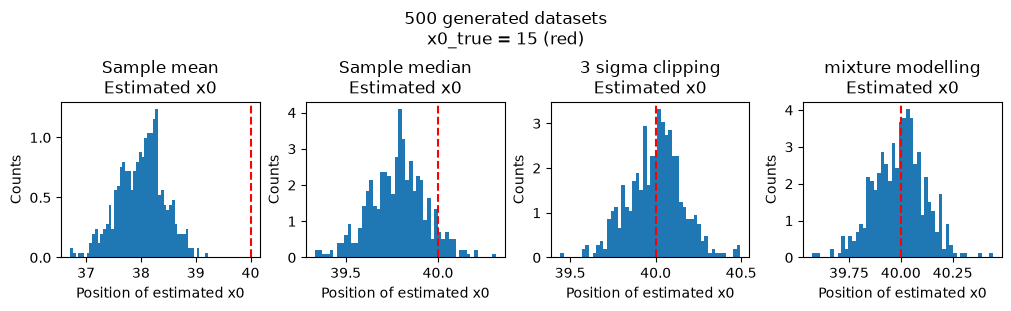

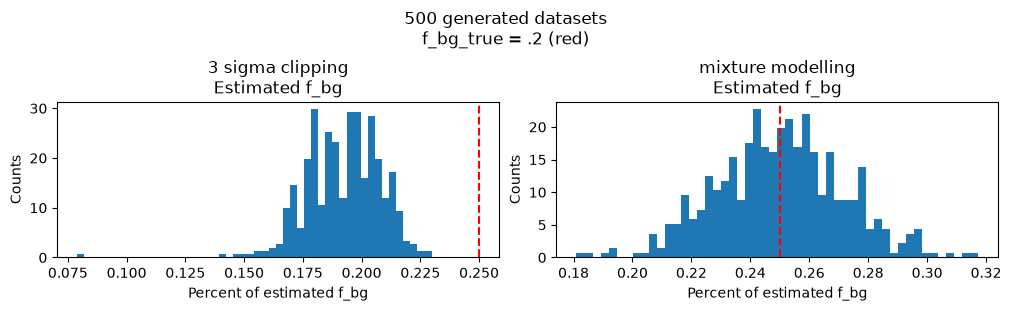

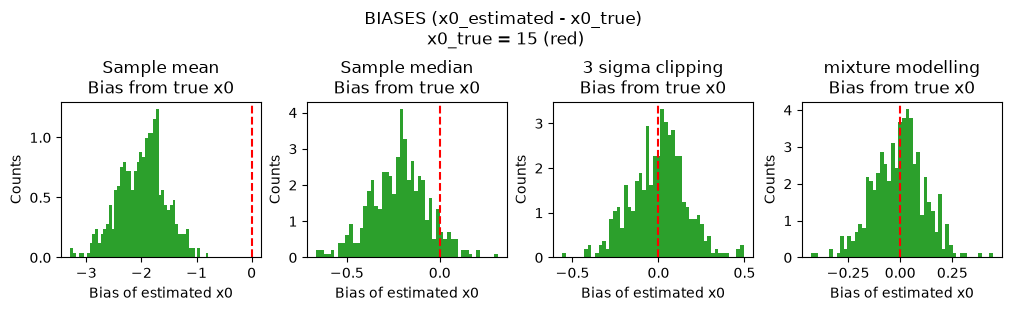

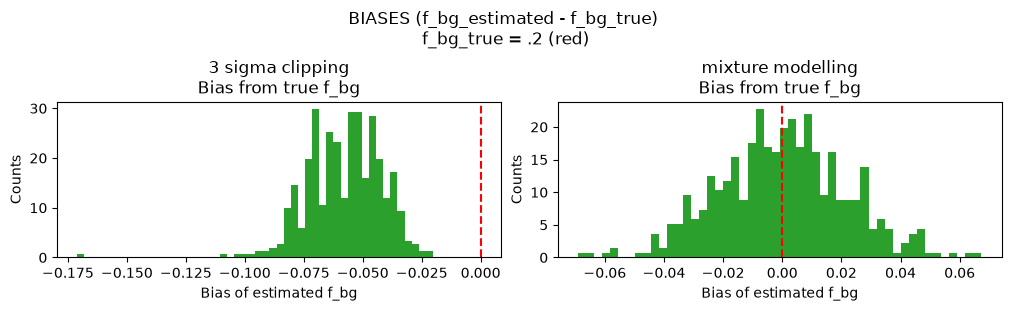

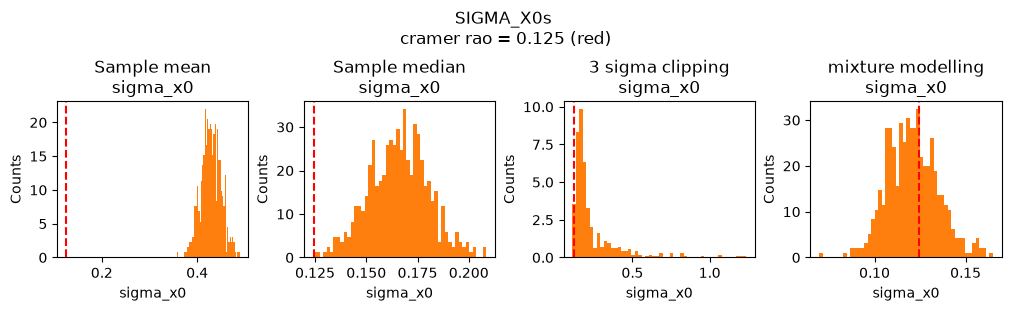

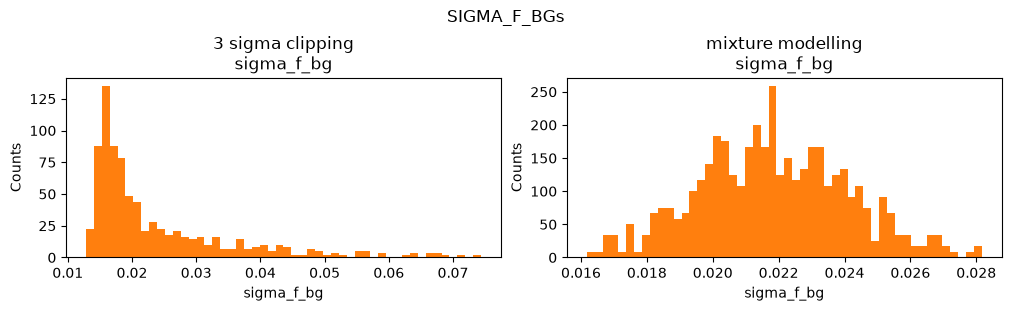

In [12]:
fig, ax = plt.subplots(1, 4, figsize=(10, 3), constrained_layout=True)
bins=50
for i, (x0s, title) in enumerate(zip(
  [mean_x0, median_x0, clip_x0, mix_x0],
  ['Sample mean', 'Sample median', '3 sigma clipping', 'mixture modelling']
)):
    ax[i].hist(x0s, bins=bins, density=True, color='tab:blue')
    ax[i].axvline(x0_true, c='r', ls='--')
    ax[i].set_title(title + "\nEstimated x0" )
    ax[i].set_xlabel('Position of estimated x0'), ax[i].set_ylabel('Counts')
fig.suptitle('500 generated datasets\nx0_true = 15 (red)')
plt.show()
fig, ax = plt.subplots(1, 2, figsize=(10, 3), constrained_layout=True)
bins=50
for i, (fbgs, title) in enumerate(zip(
  [clip_fbg, mix_fbg],
  ['3 sigma clipping', 'mixture modelling']
)):
    ax[i].hist(fbgs, bins=bins, density=True, color='tab:blue')
    ax[i].axvline(f_bg_true, c='r', ls='--')
    ax[i].set_title(title + "\nEstimated f_bg" )
    ax[i].set_xlabel('Percent of estimated f_bg'), ax[i].set_ylabel('Counts')
fig.suptitle('500 generated datasets\nf_bg_true = .2 (red)')
plt.show()


fig, ax = plt.subplots(1, 4, figsize=(10, 3), constrained_layout=True)
bins=50
for i, (x0s, title) in enumerate(zip(
  [mean_x0, median_x0, clip_x0, mix_x0],
  ['Sample mean', 'Sample median', '3 sigma clipping', 'mixture modelling']
)):
    ax[i].hist(np.array(x0s) - x0_true, bins=bins, density=True, color='tab:green')
    ax[i].axvline(0, c='r', ls='--')
    ax[i].set_title(title + "\nBias from true x0")
    ax[i].set_xlabel('Bias of estimated x0'), ax[i].set_ylabel('Counts')
fig.suptitle('BIASES (x0_estimated - x0_true) \nx0_true = 15 (red)')
plt.show()
fig, ax = plt.subplots(1, 2, figsize=(10, 3), constrained_layout=True)
bins=50
for i, (fbgs, title) in enumerate(zip(
  [clip_fbg, mix_fbg],
  ['3 sigma clipping', 'mixture modelling']
)):
    ax[i].hist(np.array(fbgs) - f_bg_true, bins=bins, density=True, color='tab:green')
    ax[i].axvline(0, c='r', ls='--')
    ax[i].set_title(title + "\nBias from true f_bg")
    ax[i].set_xlabel('Bias of estimated f_bg'), ax[i].set_ylabel('Counts')
fig.suptitle('BIASES (f_bg_estimated - f_bg_true) \nf_bg_true = .2 (red)')
plt.show()


fig, ax = plt.subplots(1, 4, figsize=(10, 3), constrained_layout=True)
bins=50
for i, (sigmas, title) in enumerate(zip(
  [mean_sigma, median_sigma, clip_sigma, mix_sigma],
  ['Sample mean', 'Sample median', '3 sigma clipping', 'mixture modelling']
)):
    ax[i].hist(sigmas, bins=bins, density=True, color='tab:orange')
    ax[i].axvline(0.12460471888341842, c='r', ls='--')
    ax[i].set_title(title + "\nsigma_x0")
    ax[i].set_xlabel('sigma_x0'), ax[i].set_ylabel('Counts')
fig.suptitle('SIGMA_X0s \ncramer rao = 0.125 (red)')
plt.show()
fig, ax = plt.subplots(1, 2, figsize=(10, 3), constrained_layout=True)
bins=50
for i, (sigmas, title) in enumerate(zip(
  [clip_fbgSigma, mix_fbgSigma],
  ['3 sigma clipping', 'mixture modelling']
)):
    ax[i].hist(sigmas, bins=bins, density=True, color='tab:orange')
    ax[i].set_title(title + "\nsigma_f_bg")
    ax[i].set_xlabel('sigma_f_bg'), ax[i].set_ylabel('Counts')
fig.suptitle('SIGMA_F_BGs')
plt.show()

Coverage of x0
	Sample mean: 0.0%
	Sample median: 35.6%
	3 sigma clipping: 80.2%
	mixture modelling: 68.6%


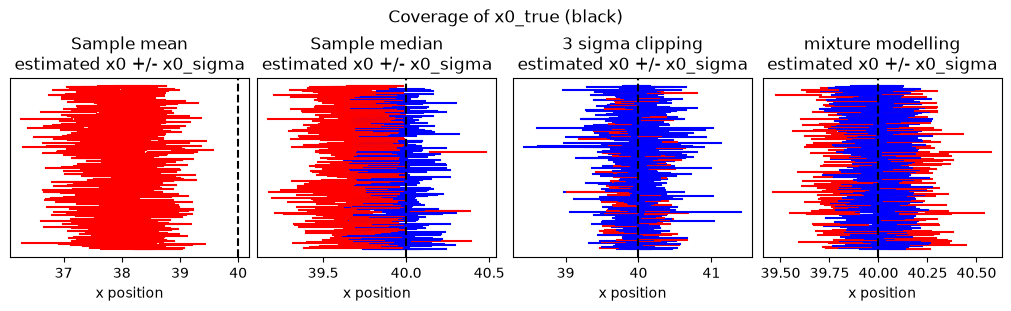

Coverage of f_bg
	3 sigma clipping: 7.2%
	mixture modelling: 69.0%


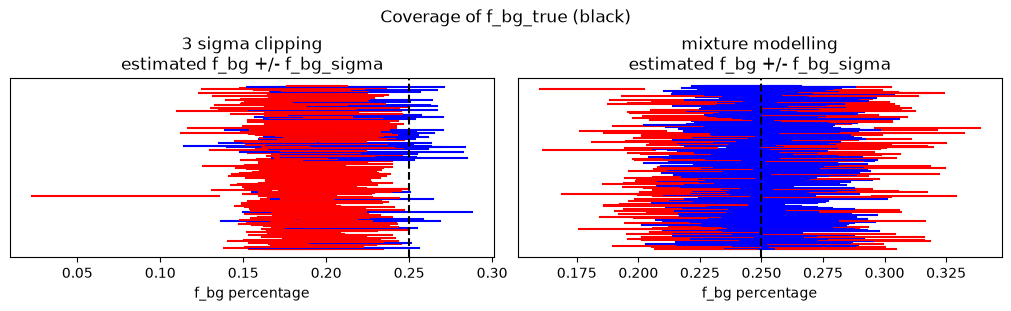

In [14]:
fig, ax = plt.subplots(1, 4, figsize=(10, 3), constrained_layout=True)
bins=50

print('Coverage of x0')
for i, (x0s, sigmas, title) in enumerate(zip(
  [mean_x0, median_x0, clip_x0, mix_x0],
  [mean_sigma, median_sigma, clip_sigma, mix_sigma],
  ['Sample mean', 'Sample median', '3 sigma clipping', 'mixture modelling']
)):
  x0s = np.array(x0s)
  sigmas = np.array(sigmas)
  bias = np.array(x0s) - x0_true
  isCovered = np.array(sigmas) > np.abs(bias)
  percentCover = 100 * np.sum(isCovered) / len(mean_x0)
  print('\t' + title + f': {percentCover}%')

  for j in range(len(x0s)):
    ax[i].plot([x0s[j] - sigmas[j], x0s[j] + sigmas[j]], [j,j], c='b' if isCovered[j] else 'r')
  ax[i].axvline(x0_true, c='k', ls='--')
  ax[i].set_yticks([]); ax[i].set_xlabel('x position')
  ax[i].set_title(title + '\nestimated x0 +/- x0_sigma')
fig.suptitle('Coverage of x0_true (black)')
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 3), constrained_layout=True)
bins=50

print('Coverage of f_bg')
for i, (fbgs, sigmas, title) in enumerate(zip(
  [clip_fbg, mix_fbg],
  [clip_fbgSigma, mix_fbgSigma],
  ['3 sigma clipping', 'mixture modelling']
)):
  fbgs = np.array(fbgs)
  sigmas = np.array(sigmas)
  bias = np.array(fbgs) - f_bg_true
  isCovered = np.array(sigmas) > np.abs(bias)
  percentCover = 100 * np.sum(isCovered) / len(fbgs)
  print('\t' + title + f': {percentCover}%')

  for j in range(len(fbgs)):
    ax[i].plot([fbgs[j] - sigmas[j], fbgs[j] + sigmas[j]], [j,j], c='b' if isCovered[j] else 'r')
  ax[i].axvline(f_bg_true, c='k', ls='--')
  ax[i].set_yticks([]); ax[i].set_xlabel('f_bg percentage')
  ax[i].set_title(title + '\nestimated f_bg +/- f_bg_sigma')
fig.suptitle('Coverage of f_bg_true (black)')
plt.show()


Text(0.5, 0.98, 'Mixture model with varying r0')

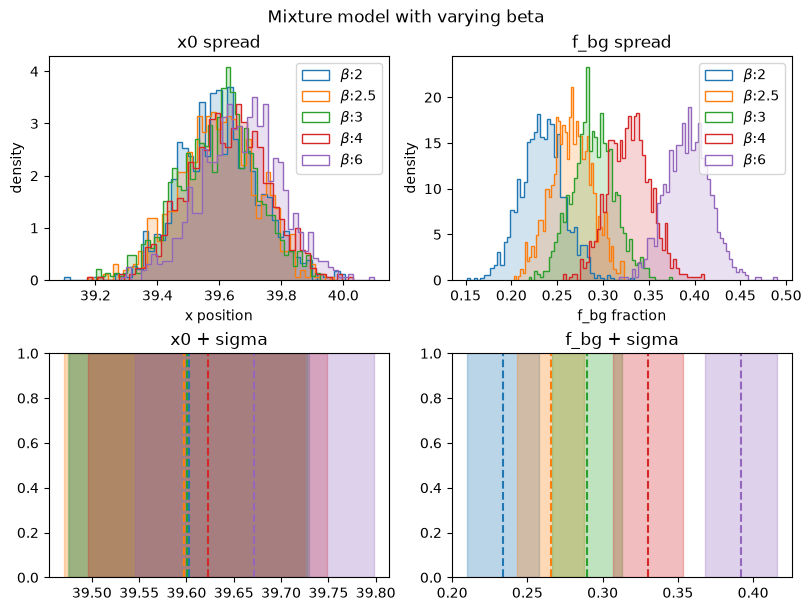

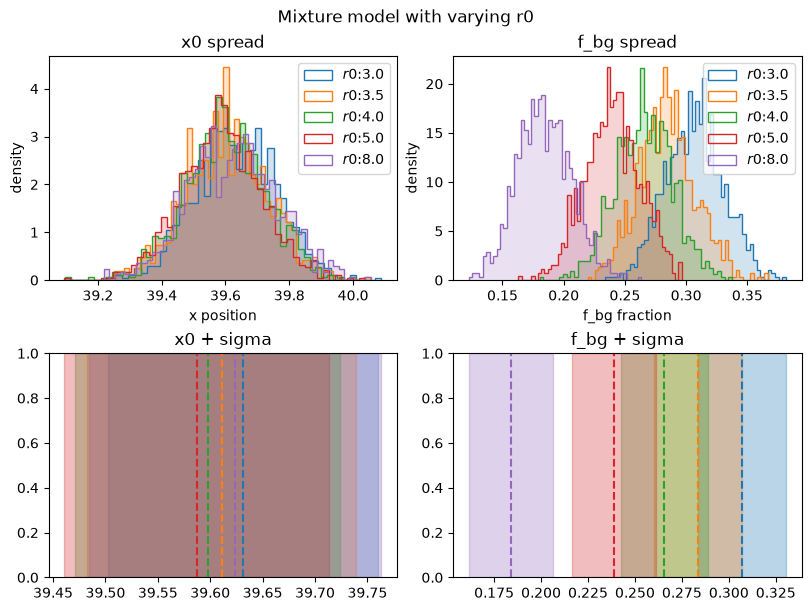

In [28]:
#Re fit the original data with different beta, r0
beta = 2.5
r0 = 4.0

fig, ax = plt.subplots(2, 2, figsize=(8,6), constrained_layout=True)
bins = np.linspace(0, 64, 100)
alpha=.2
for i, (beta, c) in enumerate(zip(
    [2, 2.5, 3, 4, 6], 
    ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
)):
    def p(x, x0, f_bg):
        star = gamma(beta) / (r0 * np.sqrt(np.pi) * gamma(beta - 0.5)) * \
            (1.0 + ((x - x0) / r0)**2)**(-beta)
        return f_bg / 64.0 + (1.0 - f_bg) * star

    #Use k sigma clip for a initial guess for x0, f_bg
    theta0 = [sampleMedian, np.mean(~maskClipped)]
    result = minimize(neg_log_likelihood, theta0, args=(data,), method='Nelder-Mead')
    x0_mix, f_bg_mix = result.x

    #bootstrap for sigma
    n_boot=1000
    n = len(data)
    x0_mixBoots = np.empty(n_boot)
    f_bg_mixBoots = np.empty(n_boot)
    for j in range(n_boot):
        idx = rng_bs.integers(0, n, size=n)
        result_boot = minimize(neg_log_likelihood, [x0_mix, f_bg_mix],
            args=(data[idx],),method='Nelder-Mead')
        x0_mixBoots[j], f_bg_mixBoots[j] = result_boot.x
    x0_mixSigma = np.std(x0_mixBoots)
    f_bg_mixSigma = np.std(f_bg_mixBoots)

    bins=50
    ax[0,0].hist(x0_mixBoots, bins=bins, histtype='step', edgecolor=c, density=True,
               label=r'$\beta$:'+f'{beta}')
    ax[0,0].hist(x0_mixBoots, bins=bins, alpha=alpha, facecolor=c, density=True)
    ax[0,1].hist(f_bg_mixBoots, bins=bins, histtype='step', edgecolor=c, density=True,
               label=r'$\beta$:'+f'{beta}')
    ax[0,1].hist(f_bg_mixBoots, bins=bins, alpha=alpha, facecolor=c, density=True,)
    ax[1,0].axvline(x0_mix, c=c, ls='--')
    ax[1,0].axvspan(x0_mix-x0_mixSigma, x0_mix+x0_mixSigma, alpha=.3, color=c)
    ax[1,1].axvline(f_bg_mix, c=c, ls='--')
    ax[1,1].axvspan(f_bg_mix-f_bg_mixSigma, f_bg_mix+f_bg_mixSigma, alpha=.3, color=c)

ax[0,0].legend(); ax[0,1].legend()
ax[0,0].set_xlabel('x position'); ax[0,1].set_xlabel('f_bg fraction')
ax[0,0].set_ylabel('density'); ax[0,1].set_ylabel('density')
ax[0,0].set_title('x0 spread'); ax[0,1].set_title('f_bg spread')
ax[1,0].set_title('x0 + sigma'); ax[1,1].set_title('f_bg + sigma')
fig.suptitle('Mixture model with varying beta')



#Re fit the original data with different beta, r0
beta = 2.5
r0 = 4.0

fig, ax = plt.subplots(2, 2, figsize=(8,6), constrained_layout=True)
bins = np.linspace(0, 64, 100)
alpha=.2
for i, (r0, c) in enumerate(zip(
    [3.0, 3.5, 4.0, 5.0, 8.0], 
    ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
)):
    def p(x, x0, f_bg):
        star = gamma(beta) / (r0 * np.sqrt(np.pi) * gamma(beta - 0.5)) * \
            (1.0 + ((x - x0) / r0)**2)**(-beta)
        return f_bg / 64.0 + (1.0 - f_bg) * star

    #Use k sigma clip for a initial guess for x0, f_bg
    theta0 = [sampleMedian, np.mean(~maskClipped)]
    result = minimize(neg_log_likelihood, theta0, args=(data,), method='Nelder-Mead')
    x0_mix, f_bg_mix = result.x

    #bootstrap for sigma
    n_boot=1000
    n = len(data)
    x0_mixBoots = np.empty(n_boot)
    f_bg_mixBoots = np.empty(n_boot)
    for j in range(n_boot):
        idx = rng_bs.integers(0, n, size=n)
        result_boot = minimize(neg_log_likelihood, [x0_mix, f_bg_mix],
            args=(data[idx],),method='Nelder-Mead')
        x0_mixBoots[j], f_bg_mixBoots[j] = result_boot.x
    x0_mixSigma = np.std(x0_mixBoots)
    f_bg_mixSigma = np.std(f_bg_mixBoots)

    bins=50
    ax[0,0].hist(x0_mixBoots, bins=bins, histtype='step', edgecolor=c, density=True,
               label=r'$r0$:'+f'{r0}')
    ax[0,0].hist(x0_mixBoots, bins=bins, alpha=alpha, facecolor=c, density=True)
    ax[0,1].hist(f_bg_mixBoots, bins=bins, histtype='step', edgecolor=c, density=True,
               label=r'$r0$:'+f'{r0}')
    ax[0,1].hist(f_bg_mixBoots, bins=bins, alpha=alpha, facecolor=c, density=True,)
    ax[1,0].axvline(x0_mix, c=c, ls='--')
    ax[1,0].axvspan(x0_mix-x0_mixSigma, x0_mix+x0_mixSigma, alpha=.3, color=c)
    ax[1,1].axvline(f_bg_mix, c=c, ls='--')
    ax[1,1].axvspan(f_bg_mix-f_bg_mixSigma, f_bg_mix+f_bg_mixSigma, alpha=.3, color=c)

ax[0,0].legend(); ax[0,1].legend()
ax[0,0].set_xlabel('x position'); ax[0,1].set_xlabel('f_bg fraction')
ax[0,0].set_ylabel('density'); ax[0,1].set_ylabel('density')
ax[0,0].set_title('x0 spread'); ax[0,1].set_title('f_bg spread')
ax[1,0].set_title('x0 + sigma'); ax[1,1].set_title('f_bg + sigma')
fig.suptitle('Mixture model with varying r0')

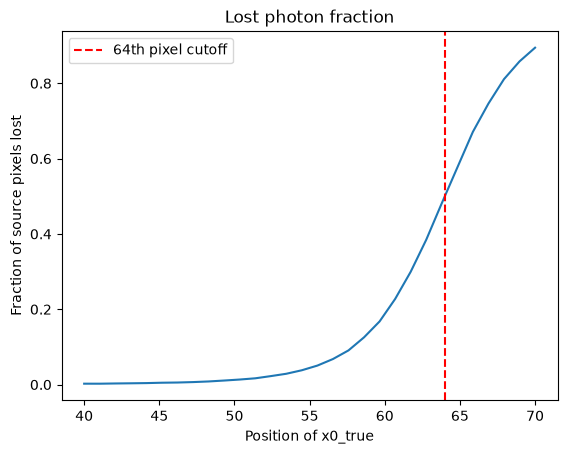

Text(0.5, 1.0, 'Lost photon fraction impact on estimating x0')

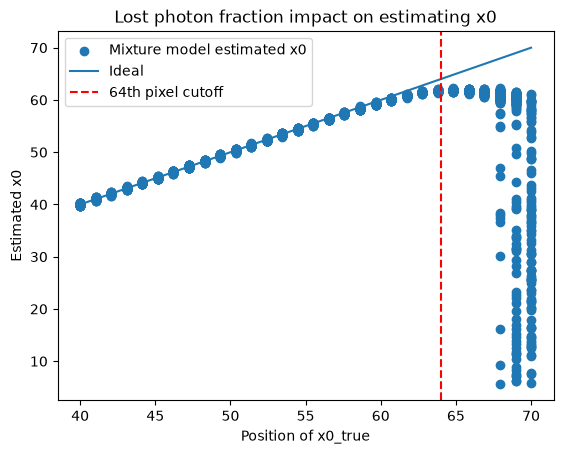

In [49]:
#Varying x0_true to see how many photons are lost

x0_true = 40
f_bg_true = .25

x0_trues = np.linspace(40, 70, 30)
lostPhotons = []
N = 100000
for x0_true in x0_trues:
    x = x0_true + r0 / np.sqrt(2*beta - 1) * t.rvs(df=2*beta - 1, size=N)
    lostPhotons.append(np.sum((x < 0) | (x > 64)))
lostPhotons = np.array(lostPhotons)
plt.plot(x0_trues, lostPhotons/N)
ax = plt.gca()
ax.axvline(64, c='r', ls='--', label='64th pixel cutoff')
plt.xlabel('Position of x0_true'); plt.ylabel('Fraction of source pixels lost')
plt.title('Lost photon fraction'); plt.legend();plt.show()


x0_estimates = []
for x0_true in x0_trues:
    for k in range(100):
        dataNew = simulate_dataset(len(data),x0_true, f_bg_true)
        result = minimize(neg_log_likelihood,[x0_true, 0.2],args=(dataNew,), method='Nelder-Mead')
        x0_mix, f_bg_mix = result.x
        x0_estimates.append((x0_true, x0_mix))
x0_estimates = np.array(x0_estimates)
plt.scatter(x0_estimates[:,0], x0_estimates[:,1], label='Mixture model estimated x0')
plt.plot(x0_trues, x0_trues, label='Ideal')
ax = plt.gca()
ax.axvline(64, c='r', ls='--', label='64th pixel cutoff')
plt.ylabel("Estimated x0"); plt.xlabel('Position of x0_true')
plt.legend(); plt.title('Lost photon fraction impact on estimating x0')

**WHAT THE CHECKS FOUND:**

With regards to closure and coverage checks: We found that the sample mean is consistently extremely poor at capturing the true x0, since it never guesses x0 within 1 sigma. It's just always too biased by noise, and the guessed x0 is always pulled towards the center of the detector x ~ 30. While the sample median is able to capture x0_true within 1 sigma a little more often, it is extremely biased. This bias is also likely due to the center of the detector being x~30.  We find that 3 sigma clipping does pretty okay. It captures x0_true within 1 sigma ~80% of the time, but it isn't able to cover f_bg_true very well at all, only ~10% of the time. It consistently underestimates the amount of background pixels. We find that mixture modeling captures x0_true within 1 sigma ~68% of the time, which is pretty similar to our random gaussian 68% we were looking for. We also find that it's able to capture f_bg ~65% of the time, which is also pretty similar to random gaussian 68%. This means that the mixture model estimator has nice closure and coverage. 

The bias/efficiency check is mostly passed by the sigma clip method, and passed much better by the mixture modelling method. The sample mean and median consistently don't meet the cramer rao minimum error, while the sigma clip and mixture model methods are able to meet the cramer rao minimum error more frequently. However, it looks like the sigma clip method has a huge spread of large sigma_x0, implying that it's probably not the most efficient method at estimating x0. For estimating x0, the sigma clip and mixture model methods have both symmetric biases, while sample mean/median methods are noticably biased. For estimating f_bg, the sigma clip method is noticably extremely biased, while the mixture model is nice and symmetric. Additionally, for estimating sigma_f_bg, the sigma clip method has a much larger spread of sigmas than the mixture model is able to achieve. 

It looks like the model is pretty sensitive to lost photons if the source position happens to be located close to the edge of the detector. However, it seems to be pretty reliable and consistent at estimating source position for a range of 5 < x < 59. Since my estimate for x0 is pretty far from the edges of this range, i'm confident there is no lost photon effect that's changing my estimate. 
Also, i find that the x0 estimate is hardly sensitive to variance in r0 or beta at all. However, the f_bg estimate seems to vary a lot. So if i were to pick this model, i would want to try fitting for r0 and beta, since it seems to impact f_bg a large extent.


## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true. (Your verification plan lives in Part 3 this week; it earned a
promotion. If an AI wrote any of it, that belongs here too.)

**AI-USE APPENDIX:**

I used chatgpt to help me write the function for the mixture model since i didn't know how to use scipy.special.gamma. I was also confused about what the instructions were saying about the cramer rao thing, so i asked chatgpt to help me understand what we were doing & what this number means.

I also used it to help me understand what the directions meant by 'lost photon fraction'.

I used it when i got an error with matplotlib method arguments, since i didn't understand why plt.scatter didn't like certain argument names.